Mounted at /content/drive
Data Loaded.
Shape: (4269, 13)

----- DESCRIPTIVE STATISTICS -----
           loan_id   no_of_dependents   income_annum   loan_amount  \
count  4269.000000        4269.000000   4.269000e+03  4.269000e+03   
mean   2135.000000           2.498712   5.059124e+06  1.513345e+07   
std    1232.498479           1.695910   2.806840e+06  9.043363e+06   
min       1.000000           0.000000   2.000000e+05  3.000000e+05   
25%    1068.000000           1.000000   2.700000e+06  7.700000e+06   
50%    2135.000000           3.000000   5.100000e+06  1.450000e+07   
75%    3202.000000           4.000000   7.500000e+06  2.150000e+07   
max    4269.000000           5.000000   9.900000e+06  3.950000e+07   

         loan_term   cibil_score   residential_assets_value  \
count  4269.000000   4269.000000               4.269000e+03   
mean     10.900445    599.936051               7.472617e+06   
std       5.709187    172.430401               6.503637e+06   
min       2.000000    30

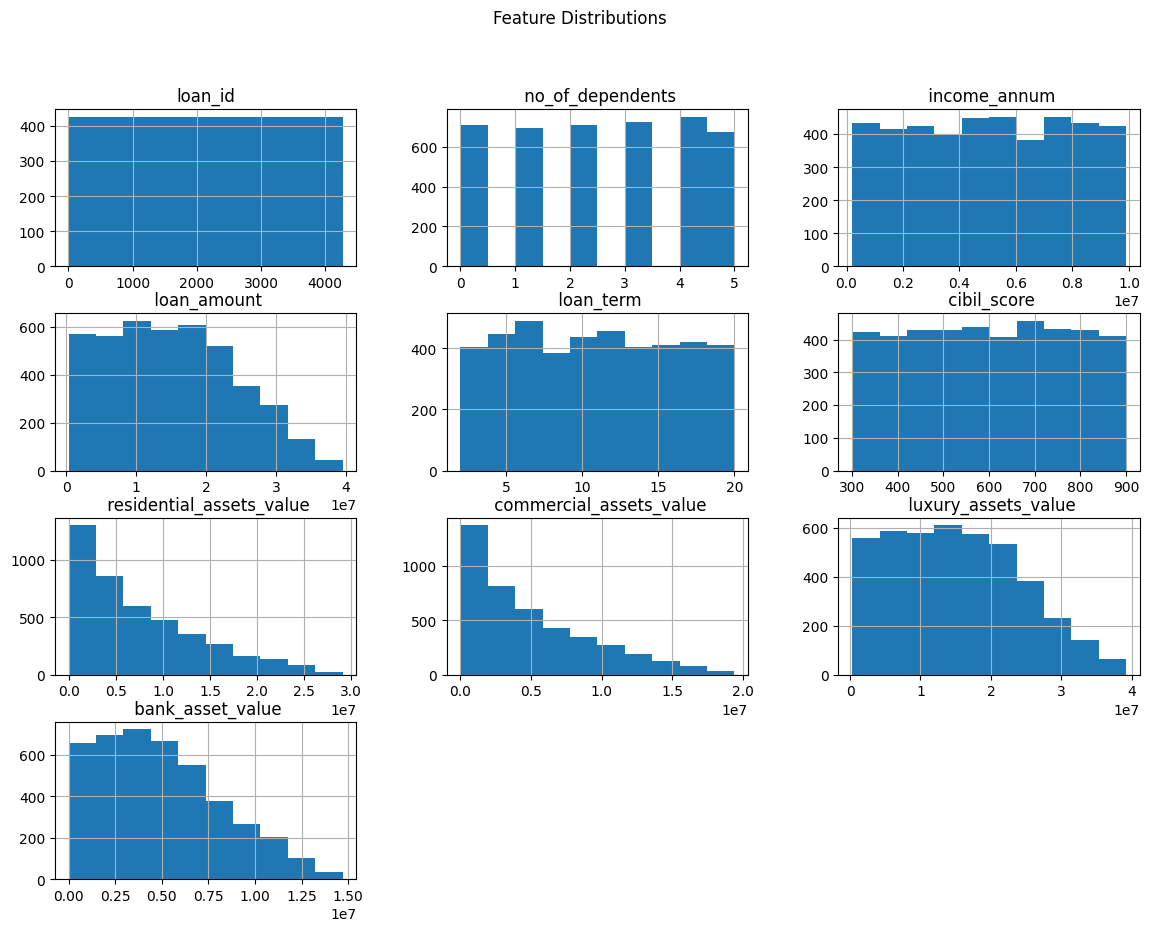

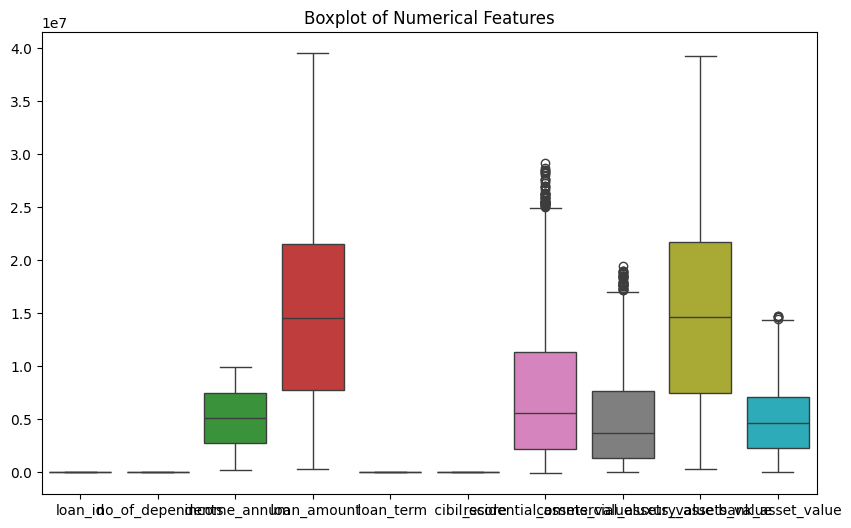


----- CORRELATION MATRIX -----


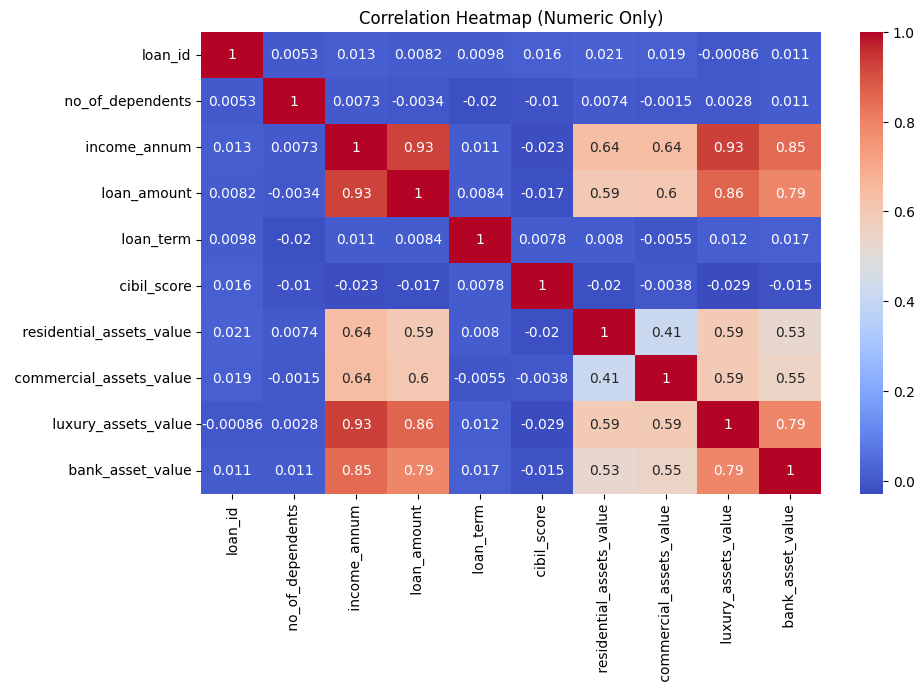


PCA Explained Variance: [0.40744221 0.09408698]

----- TRAINING CLASSIFICATION MODELS -----
KNN trained successfully.
Naive Bayes trained successfully.
Logistic Regression trained successfully.
Random Forest trained successfully.

----- MODEL EVALUATION -----

Model: KNN
Accuracy: 0.5761124121779859
Confusion Matrix:
 [[378 158]
 [204 114]]
Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.71      0.68       536
           1       0.42      0.36      0.39       318

    accuracy                           0.58       854
   macro avg       0.53      0.53      0.53       854
weighted avg       0.56      0.58      0.57       854


Model: Naive Bayes
Accuracy: 0.629976580796253
Confusion Matrix:
 [[532   4]
 [312   6]]
Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.99      0.77       536
           1       0.60      0.02      0.04       318

    accuracy               

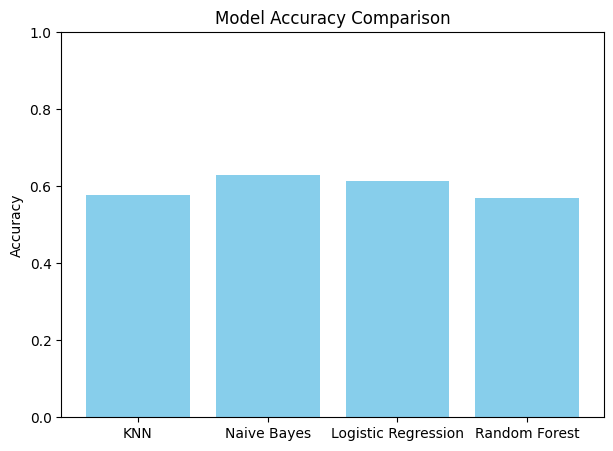


----- ROC CURVES -----


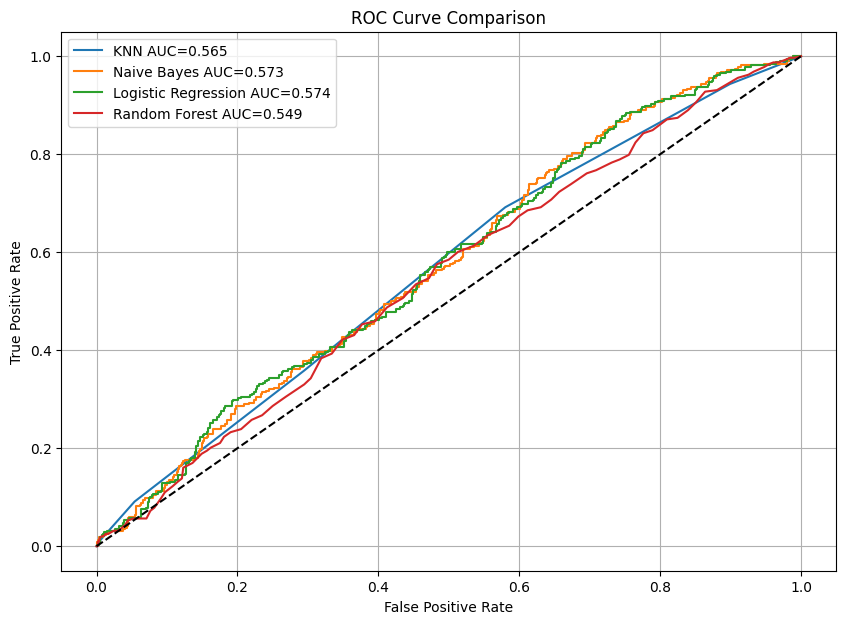


----- CROSS VALIDATION -----
KNN CV Accuracy: 0.5622
Naive Bayes CV Accuracy: 0.7604
Logistic Regression CV Accuracy: 0.7943
Random Forest CV Accuracy: 0.9810

----- HYPERPARAMETER TUNING (Random Forest) -----
Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}

Optimized Model Accuracy: 0.9742388758782201


In [1]:
# ------------------------------
# 1. IMPORT NECESSARY LIBRARIES
# ------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importing machine learning utilities
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc
)

# Importing classifiers
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA

# For mounting Google Drive in Colab
from google.colab import drive


# ------------------------------
# 2. DEFINE THE LOAN PREDICTOR CLASS
# ------------------------------
class LoanApprovalPredictor:

    def __init__(self, file_path):
        """
        Initialize the predictor with the CSV file path.
        """
        self.file_path = file_path
        self.data = None
        self.X_train, self.X_test, self.y_train, self.y_test = None, None, None, None
        self.scaler = None
        self.models = {}
        self.X_pca_train = None
        self.X_pca_test = None
        self.pca = None

    @classmethod
    def mount_drive(cls):
        """
        Mount Google Drive in Colab.
        """
        drive.mount('/content/drive', force_remount=True)

    # ------------------------------
    # 3. DATA LOADING
    # ------------------------------
    def load_data(self):
        """
        Load CSV data into a pandas DataFrame.
        """
        self.data = pd.read_csv(self.file_path)
        print("Data Loaded.\nShape:", self.data.shape)

    # ------------------------------
    # 4. DESCRIPTIVE STATISTICS
    # ------------------------------
    def descriptive_statistics(self):
        """
        Display descriptive statistics, skewness, kurtosis, histograms, and boxplots.
        """
        print("\n----- DESCRIPTIVE STATISTICS -----")
        print(self.data.describe())

        # Select only numerical features
        numeric_df = self.data.select_dtypes(include=['int64', 'float64'])

        # Skewness measures asymmetry
        print("\nSkewness:\n", numeric_df.skew())

        # Kurtosis measures "tailedness"
        print("\nKurtosis:\n", numeric_df.kurt())

        # Plot histograms
        numeric_df.hist(figsize=(14, 10))
        plt.suptitle("Feature Distributions")
        plt.show()

        # Boxplots for detecting outliers
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=numeric_df)
        plt.title("Boxplot of Numerical Features")
        plt.show()

    # ------------------------------
    # 5. CORRELATION ANALYSIS
    # ------------------------------
    def correlation_analysis(self):
        """
        Plot correlation heatmap of numeric features.
        """
        print("\n----- CORRELATION MATRIX -----")
        numeric_df = self.data.select_dtypes(include=['int64', 'float64'])
        plt.figure(figsize=(10, 6))
        sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
        plt.title("Correlation Heatmap (Numeric Only)")
        plt.show()

    # ------------------------------
    # 6. DATA PREPROCESSING
    # ------------------------------
    def preprocess_data(self):
        """
        Handle missing values, encode categorical features, and separate X/y.
        """
        # Standardize column names
        self.data.columns = self.data.columns.str.strip().str.lower()

        # Separate numerical and categorical columns
        num_cols = self.data.select_dtypes(include=["int64", "float64"]).columns
        cat_cols = self.data.select_dtypes(include=["object"]).columns

        # Fill missing numerical values with mean
        self.data[num_cols] = self.data[num_cols].fillna(self.data[num_cols].mean())

        # Fill missing categorical values with mode
        for col in cat_cols:
            self.data[col] = self.data[col].fillna(self.data[col].mode()[0])

        # Replace "3+" dependents with numeric 3
        if "no_of_dependents" in self.data.columns:
            self.data["no_of_dependents"] = self.data["no_of_dependents"].replace("3+", 3)

        # Label encoding for categorical features
        target_col = "loan_status"
        encoder = LabelEncoder()
        for col in cat_cols:
            if col != target_col:
                self.data[col] = encoder.fit_transform(self.data[col])

        # Encode target variable as 0/1
        if target_col in self.data.columns:
            self.data[target_col] = encoder.fit_transform(self.data[target_col])

        # Drop unique ID column
        if "loan_id" in self.data.columns:
            self.data.drop(columns=["loan_id"], inplace=True)

        # Separate features and target
        self.X = self.data.drop(columns=[target_col])
        self.y = self.data[target_col]

    # ------------------------------
    # 7. SPLIT AND SCALE DATA
    # ------------------------------
    def split_and_scale(self):
        """
        Split data into train/test and apply standard scaling and PCA.
        """
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, test_size=0.2, random_state=42
        )

        # Standard scaling to normalize features
        self.scaler = StandardScaler()
        self.X_train = self.scaler.fit_transform(self.X_train)
        self.X_test = self.scaler.transform(self.X_test)

        # Apply PCA for dimensionality reduction
        self.pca = PCA(n_components=2)
        self.X_pca_train = self.pca.fit_transform(self.X_train)
        self.X_pca_test = self.pca.transform(self.X_test)

        print("\nPCA Explained Variance:", self.pca.explained_variance_ratio_)

    # ------------------------------
    # 8. TRAIN CLASSIFICATION MODELS
    # ------------------------------
    def train_classification_models(self):
        """
        Train multiple classifiers using PCA-transformed features.
        """
        print("\n----- TRAINING CLASSIFICATION MODELS -----")

        model_dict = {
            "KNN": KNeighborsClassifier(),
            "Naive Bayes": GaussianNB(),
            "Logistic Regression": LogisticRegression(max_iter=1000),
            "Random Forest": RandomForestClassifier(random_state=42)
        }

        for name, model in model_dict.items():
            model.fit(self.X_pca_train, self.y_train)
            self.models[name] = model
            print(f"{name} trained successfully.")

    # ------------------------------
    # 9. EVALUATE MODELS
    # ------------------------------
    def evaluate_models(self):
        """
        Evaluate models using accuracy, confusion matrix, and classification report.
        """
        print("\n----- MODEL EVALUATION -----")
        results = {}

        for name, model in self.models.items():
            y_pred = model.predict(self.X_pca_test)
            acc = accuracy_score(self.y_test, y_pred)
            results[name] = acc

            print(f"\nModel: {name}")
            print("Accuracy:", acc)
            print("Confusion Matrix:\n", confusion_matrix(self.y_test, y_pred))
            print("Classification Report:\n", classification_report(self.y_test, y_pred))

        # Plot accuracy comparison
        plt.figure(figsize=(7, 5))
        plt.bar(results.keys(), results.values(), color='skyblue')
        plt.title("Model Accuracy Comparison")
        plt.ylabel("Accuracy")
        plt.ylim(0, 1)
        plt.show()

    # ------------------------------
    # 10. ROC CURVES
    # ------------------------------
    def plot_roc_curves(self):
        """
        Plot ROC curves for all models that support probability predictions.
        """
        print("\n----- ROC CURVES -----")
        plt.figure(figsize=(10, 7))

        for name, model in self.models.items():
            if hasattr(model, "predict_proba"):
                y_prob = model.predict_proba(self.X_pca_test)[:, 1]
                fpr, tpr, _ = roc_curve(self.y_test, y_prob)
                roc_auc = auc(fpr, tpr)
                plt.plot(fpr, tpr, label=f"{name} AUC={roc_auc:.3f}")

        plt.plot([0, 1], [0, 1], "k--")
        plt.title("ROC Curve Comparison")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend()
        plt.grid(True)
        plt.show()

    # ------------------------------
    # 11. CROSS VALIDATION
    # ------------------------------
    def cross_validation(self):
        """
        Perform 5-fold cross-validation for all models.
        """
        print("\n----- CROSS VALIDATION -----")
        for name, model in self.models.items():
            scores = cross_val_score(model, self.X, self.y, cv=5)
            print(f"{name} CV Accuracy: {scores.mean():.4f}")

    # ------------------------------
    # 12. HYPERPARAMETER TUNING
    # ------------------------------
    def hyperparameter_tuning(self):
        """
        Perform GridSearchCV to tune Random Forest hyperparameters.
        """
        print("\n----- HYPERPARAMETER TUNING (Random Forest) -----")
        param_grid = {
            "n_estimators": [50, 100, 200],
            "max_depth": [4, 6, 8, None],
            "min_samples_split": [2, 5, 10]
        }

        grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5)
        grid.fit(self.X_train, self.y_train)

        print("Best Parameters:", grid.best_params_)

        best_model = grid.best_estimator_
        y_pred = best_model.predict(self.X_test)
        print("\nOptimized Model Accuracy:", accuracy_score(self.y_test, y_pred))


# ------------------------------
# 13. MAIN EXECUTION
# ------------------------------
if __name__ == "__main__":
    # Mount Google Drive in Colab
    LoanApprovalPredictor.mount_drive()

    # Initialize the predictor with the dataset path
    predictor = LoanApprovalPredictor("/content/drive/MyDrive/loan_approval_dataset.csv")

    # Run all steps
    predictor.load_data()
    predictor.descriptive_statistics()
    predictor.correlation_analysis()
    predictor.preprocess_data()
    predictor.split_and_scale()
    predictor.train_classification_models()
    predictor.evaluate_models()
    predictor.plot_roc_curves()
    predictor.cross_validation()
    predictor.hyperparameter_tuning()
